


# Sesión 7: Fine-tuning de YOLOv11 con Dataset Propio

**Instructor:** Guido Anthony Chipana Calderon  
**Curso:** Especialización en Computer Vision  
**Fecha:** Marzo 2026

---

En las sesiones anteriores trabajamos con modelos pre-entrenados en COCO. Hoy el objetivo es completar el flujo real: tomar un dataset anotado en Roboflow, entender su estructura, configurar el entrenamiento correctamente y analizar los resultados con el mismo criterio que se aplicaría en un proyecto de producción.

Todo el trabajo de esta sesión se guarda en Google Drive para que los checkpoints y los resultados persistan entre sesiones de Colab.

---
## Parte 1: Google Drive y configuración del entorno

Lo primero es montar Drive y definir la estructura de carpetas donde va a vivir todo: el dataset, los resultados del entrenamiento y los modelos exportados. Si reinicias el entorno de Colab, solo necesitas volver a ejecutar desde esta celda.

In [29]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Estructura en Drive
DRIVE_BASE   = Path('/content/drive/MyDrive/curso_cv')
DATASETS_DIR = DRIVE_BASE / 'datasets'
MODELS_DIR   = DRIVE_BASE / 'models'
OUTPUTS_DIR  = DRIVE_BASE / 'outputs'

for d in [DATASETS_DIR, MODELS_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Drive montado:')
print(f'  datasets : {DATASETS_DIR}')
print(f'  models   : {MODELS_DIR}')
print(f'  outputs  : {OUTPUTS_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado:
  datasets : /content/drive/MyDrive/curso_cv/datasets
  models   : /content/drive/MyDrive/curso_cv/models
  outputs  : /content/drive/MyDrive/curso_cv/outputs


In [9]:
!pip install -q ultralytics roboflow

import ultralytics
print(f'Ultralytics: {ultralytics.__version__}')

Ultralytics: 8.4.19


In [10]:
import torch
import yaml
import random
import shutil
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from PIL import Image
from ultralytics import YOLO

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {device.upper()}')
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f'GPU     : {gpu.name}')
    print(f'VRAM    : {gpu.total_memory / 1e9:.1f} GB')
print(f'PyTorch : {torch.__version__}')

Device  : CUDA
GPU     : Tesla T4
VRAM    : 15.6 GB
PyTorch : 2.10.0+cu128


---
## Parte 2: Dataset desde Roboflow

El flujo que seguimos en clase es el siguiente: en Roboflow anotas tu dataset, configuras el data augmentation y exportas en formato YOLOv11. Roboflow te entrega un ZIP con esta estructura:

```
dataset/
├── train/
│   ├── images/
│   └── labels/
├── valid/
│   ├── images/
│   └── labels/
├── test/
│   ├── images/
│   └── labels/
└── data.yaml
```

Si exportaste con data augmentation activada, esas transformaciones se aplican únicamente al set de train. Roboflow las genera antes de que descargues el ZIP, así que el set de train ya llega aumentado. El set de validación y el de test contienen las imágenes originales sin modificar, porque ahí es donde mides el rendimiento real.

Para cargar el dataset en el notebook hay dos opciones. La primera es la que usamos en clase: descargas el ZIP desde la web de Roboflow, lo subes a tu Drive y el notebook lo descomprime automáticamente. La segunda usa la API de Roboflow para descargar directo desde el notebook, lo que evita el paso manual.

Ejecuta solo una de las dos celdas siguientes.

In [11]:
import zipfile

# Metodo 1 (recomendado): ZIP exportado desde la web de Roboflow
# --------------------------------------------------------------
# Pasos previos:
#   1. En Roboflow: Export Dataset -> Format: YOLOv11 -> Download ZIP
#   2. Sube ese ZIP a tu Drive, dentro de la carpeta curso_cv/datasets/
#   3. Ejecuta esta celda

# Buscar el ZIP en la carpeta de datasets
zips = list(DATASETS_DIR.glob('*.zip'))

if len(zips) == 0:
    raise FileNotFoundError(
        f'No se encontro ningun ZIP en {DATASETS_DIR}\n'
        f'Sube el ZIP exportado de Roboflow a esa carpeta y vuelve a ejecutar.'
    )

if len(zips) > 1:
    print(f'Varios ZIPs encontrados: {[z.name for z in zips]}')
    print(f'Usando el mas reciente: {sorted(zips)[-1].name}')

dataset_zip  = sorted(zips)[-1]
DATASET_DIR  = DATASETS_DIR / dataset_zip.stem  # carpeta con el mismo nombre que el ZIP

# Si el dataset ya fue extraido en sesiones anteriores, no lo vuelve a descomprimir
if DATASET_DIR.exists() and any(DATASET_DIR.iterdir()):
    print(f'Dataset ya disponible en: {DATASET_DIR}')
else:
    DATASET_DIR.mkdir(exist_ok=True)
    print(f'Descomprimiendo {dataset_zip.name}...')
    with zipfile.ZipFile(dataset_zip, 'r') as zf:
        zf.extractall(DATASET_DIR)
    print(f'Dataset listo en: {DATASET_DIR}')

Descomprimiendo human_tracking_2.zip...
Dataset listo en: /content/drive/MyDrive/curso_cv/datasets/human_tracking_2


In [ ]:
# Metodo 2 (alternativo): Descarga directa via API de Roboflow
# -------------------------------------------------------------
# Util si prefieres no hacer el paso manual de subir el ZIP.
# Si el dataset ya existe en Drive de una sesion anterior, Roboflow detecta
# que la carpeta no esta vacia y no repite la descarga.

from roboflow import Roboflow

API_KEY      = 'TU_API_KEY'       # Account Settings -> Roboflow API Key
WORKSPACE    = 'tu-workspace'     # Nombre del workspace en Roboflow
PROJECT_NAME = 'tu-proyecto'      # Nombre del proyecto
VERSION      = 1                  # Version del dataset a descargar

DATASET_DIR = DATASETS_DIR / PROJECT_NAME

rf      = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT_NAME)
version = project.version(VERSION)
dataset = version.download('yolov11', location=str(DATASET_DIR))

print(f'Dataset en: {DATASET_DIR}')

In [12]:
# Verificar la estructura del dataset (ejecutar despues de cualquiera de los dos metodos)
def print_tree(directory, prefix='', max_files=5):
    contents = sorted(Path(directory).iterdir())
    dirs  = [p for p in contents if p.is_dir()]
    files = [p for p in contents if p.is_file()]
    for i, path in enumerate(dirs):
        is_last = (i == len(dirs) - 1) and not files
        print(f"{prefix}{'└── ' if is_last else '├── '}{path.name}/")
        print_tree(path, prefix + ('    ' if is_last else '│   '), max_files)
    for i, path in enumerate(files[:max_files]):
        print(f"{prefix}{'└── ' if i == min(len(files), max_files) - 1 else '├── '}{path.name}")
    if len(files) > max_files:
        print(f'{prefix}    ... {len(files) - max_files} archivos mas')

print(f'{DATASET_DIR.name}/')
print_tree(DATASET_DIR)

human_tracking_2/
├── test/
│   ├── images/
│   │   └── frame_000039_PNG.rf.679c7d1e41ee47d0f0c680f81b23a4a8.jpg
│   └── labels/
│       └── frame_000039_PNG.rf.679c7d1e41ee47d0f0c680f81b23a4a8.txt
├── train/
│   ├── images/
│   │   ├── frame_000015_PNG.rf.6e3add97992c06d9f49cef248eee8d62.jpg
│   │   ├── frame_000015_PNG.rf.bb19f56ad29090ece7bd9a0145353e8b.jpg
│   │   ├── frame_000015_PNG.rf.d182cd0f579acb94623473a0b7397a64.jpg
│   │   ├── frame_000016_PNG.rf.019793cea7d1b5ea25cae7feb4140c21.jpg
│   │   └── frame_000016_PNG.rf.bd089964f2d2452941042971387adc34.jpg
│   │       ... 19 archivos mas
│   └── labels/
│       ├── frame_000015_PNG.rf.6e3add97992c06d9f49cef248eee8d62.txt
│       ├── frame_000015_PNG.rf.bb19f56ad29090ece7bd9a0145353e8b.txt
│       ├── frame_000015_PNG.rf.d182cd0f579acb94623473a0b7397a64.txt
│       ├── frame_000016_PNG.rf.019793cea7d1b5ea25cae7feb4140c21.txt
│       └── frame_000016_PNG.rf.bd089964f2d2452941042971387adc34.txt
│           ... 19 archivos mas
├── v

---
## Parte 3: data.yaml

El `data.yaml` es lo que conecta el dataset con el entrenamiento. Si hay un error aquí, el modelo se entrena con clases incorrectas o directamente no encuentra las imágenes. Conviene revisarlo explícitamente antes de lanzar cualquier entrenamiento.

Hay un detalle con el que te vas a encontrar siempre al usar Roboflow en Colab: las rutas que genera son relativas al directorio donde está el YAML, pero YOLO las resuelve desde el directorio de trabajo del proceso, que en Colab no siempre coincide. La solución más robusta es agregar la clave `path` con la ruta absoluta del dataset y mantener las rutas de `train`, `val` y `test` relativas a eso. Generamos un `data_fixed.yaml` con esa corrección y es ese el que usamos para entrenar.

In [13]:
yaml_path = DATASET_DIR / 'data.yaml'

with open(yaml_path, 'r', encoding='utf-8') as f:
    raw_content = f.read()
    data_config = yaml.safe_load(raw_content)

print('data.yaml original:')
print('=' * 50)
print(raw_content)

data.yaml original:
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['persona']

roboflow:
  workspace: guidos-workspace-wbaf7
  project: human_tracking_2
  version: 2
  license: Private
  url: https://app.roboflow.com/guidos-workspace-wbaf7/human_tracking_2/2


In [14]:
# Rutas definidas
print('Rutas:')
for key in ['train', 'val', 'valid', 'test']:
    if key in data_config:
        print(f'  {key:<6}: {data_config[key]}')

# Clases
names      = data_config['names']
names_list = names if isinstance(names, list) else [names[k] for k in sorted(names.keys())]

print(f'\nClases ({data_config["nc"]} total):')
for i, name in enumerate(names_list):
    print(f'  [{i}] {name}')

# Verificar consistencia entre nc y la cantidad de nombres
nc_ok = data_config['nc'] == len(names_list)
print(f'\nnc={data_config["nc"]} vs. {len(names_list)} nombres definidos: {"OK" if nc_ok else "MISMATCH - corregir antes de continuar"}')

# Metadata de Roboflow (no afecta el entrenamiento, solo informativa)
if 'roboflow' in data_config:
    print('\nMetadata Roboflow:')
    for k, v in data_config['roboflow'].items():
        print(f'  {k}: {v}')

Rutas:
  train : ../train/images
  val   : ../valid/images
  test  : ../test/images

Clases (1 total):
  [0] persona

nc=1 vs. 1 nombres definidos: OK

Metadata Roboflow:
  workspace: guidos-workspace-wbaf7
  project: human_tracking_2
  version: 2
  license: Private
  url: https://app.roboflow.com/guidos-workspace-wbaf7/human_tracking_2/2


In [15]:
# Detectar si Roboflow usa 'valid' o 'val' para validacion
val_key   = 'valid' if 'valid' in data_config else 'val'
val_rel   = data_config.get(val_key,  'valid/images')
train_rel = data_config.get('train',  'train/images')
test_rel  = data_config.get('test',   'test/images')

DATASET_ABS = DATASET_DIR.resolve()

print('Verificando rutas:')
for label, rel in [('train', train_rel), ('val', val_rel), ('test', test_rel)]:
    full   = DATASET_ABS / rel
    status = 'OK' if full.exists() else 'no encontrado'
    print(f'  {label}: {full}  [{status}]')

# Generar data_fixed.yaml con ruta absoluta
updated = {
    'path' : str(DATASET_ABS),
    'train': train_rel,
    'val'  : val_rel,
    'test' : test_rel,
    'nc'   : data_config['nc'],
    'names': names_list
}

yaml_fixed_path = DATASET_DIR / 'data_fixed.yaml'
with open(yaml_fixed_path, 'w', encoding='utf-8') as f:
    yaml.dump(updated, f, default_flow_style=False, sort_keys=False, allow_unicode=True)

print(f'\ndata_fixed.yaml guardado en: {yaml_fixed_path}')
print('\nContenido:')
print('-' * 40)
with open(yaml_fixed_path) as f:
    print(f.read())

Verificando rutas:
  train: /content/drive/MyDrive/curso_cv/datasets/human_tracking_2/../train/images  [no encontrado]
  val: /content/drive/MyDrive/curso_cv/datasets/human_tracking_2/../valid/images  [no encontrado]
  test: /content/drive/MyDrive/curso_cv/datasets/human_tracking_2/../test/images  [no encontrado]

data_fixed.yaml guardado en: /content/drive/MyDrive/curso_cv/datasets/human_tracking_2/data_fixed.yaml

Contenido:
----------------------------------------
path: /content/drive/MyDrive/curso_cv/datasets/human_tracking_2
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 1
names:
- persona



---
## Parte 4: Exploración del dataset

Antes de entrenar conviene entender con qué se está trabajando: cuántas imágenes hay en cada split, cómo están distribuidas las clases y qué efecto tuvo el augmentation de Roboflow. Un dataset con clases muy desbalanceadas va a tener recall bajo en las clases minoritarias, y eso se ve antes en la exploración que en las métricas de entrenamiento.

In [16]:
def count_dataset(dataset_dir):
    IMG_EXTS = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG']
    results  = {}
    splits   = {'train': ['train'], 'val': ['valid', 'val'], 'test': ['test']}

    for split_name, candidates in splits.items():
        for dir_name in candidates:
            img_dir = dataset_dir / dir_name / 'images'
            lbl_dir = dataset_dir / dir_name / 'labels'
            if img_dir.exists():
                images = []
                for ext in IMG_EXTS:
                    images.extend(img_dir.glob(ext))
                images = list(set(images))
                labels = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
                results[split_name] = {
                    'dir'      : dir_name,
                    'images'   : len(images),
                    'labels'   : len(labels),
                    'img_paths': images,
                    'lbl_dir'  : lbl_dir
                }
                break
    return results

stats = count_dataset(DATASET_DIR)

print(f"{'Split':<8} {'Carpeta':<8} {'Imagenes':>10} {'Labels':>10}")
print('-' * 42)
total = 0
for split, d in stats.items():
    mismatch = '  *' if d['images'] != d['labels'] else ''
    print(f"{split:<8} {d['dir']:<8} {d['images']:>10} {d['labels']:>10}{mismatch}")
    total += d['images']
print('-' * 42)
print(f"{'Total':<8} {'':<8} {total:>10}")

# El ratio entre train y val refleja el multiplicador de augmentation que configuraste en Roboflow
if 'train' in stats and 'val' in stats and stats['val']['images'] > 0:
    ratio = stats['train']['images'] / stats['val']['images']
    print(f'\nRatio train/val: {ratio:.1f}x')

Split    Carpeta    Imagenes     Labels
------------------------------------------
train    train            24         24
val      valid             2          2
test     test              1          1
------------------------------------------
Total                     27

Ratio train/val: 12.0x


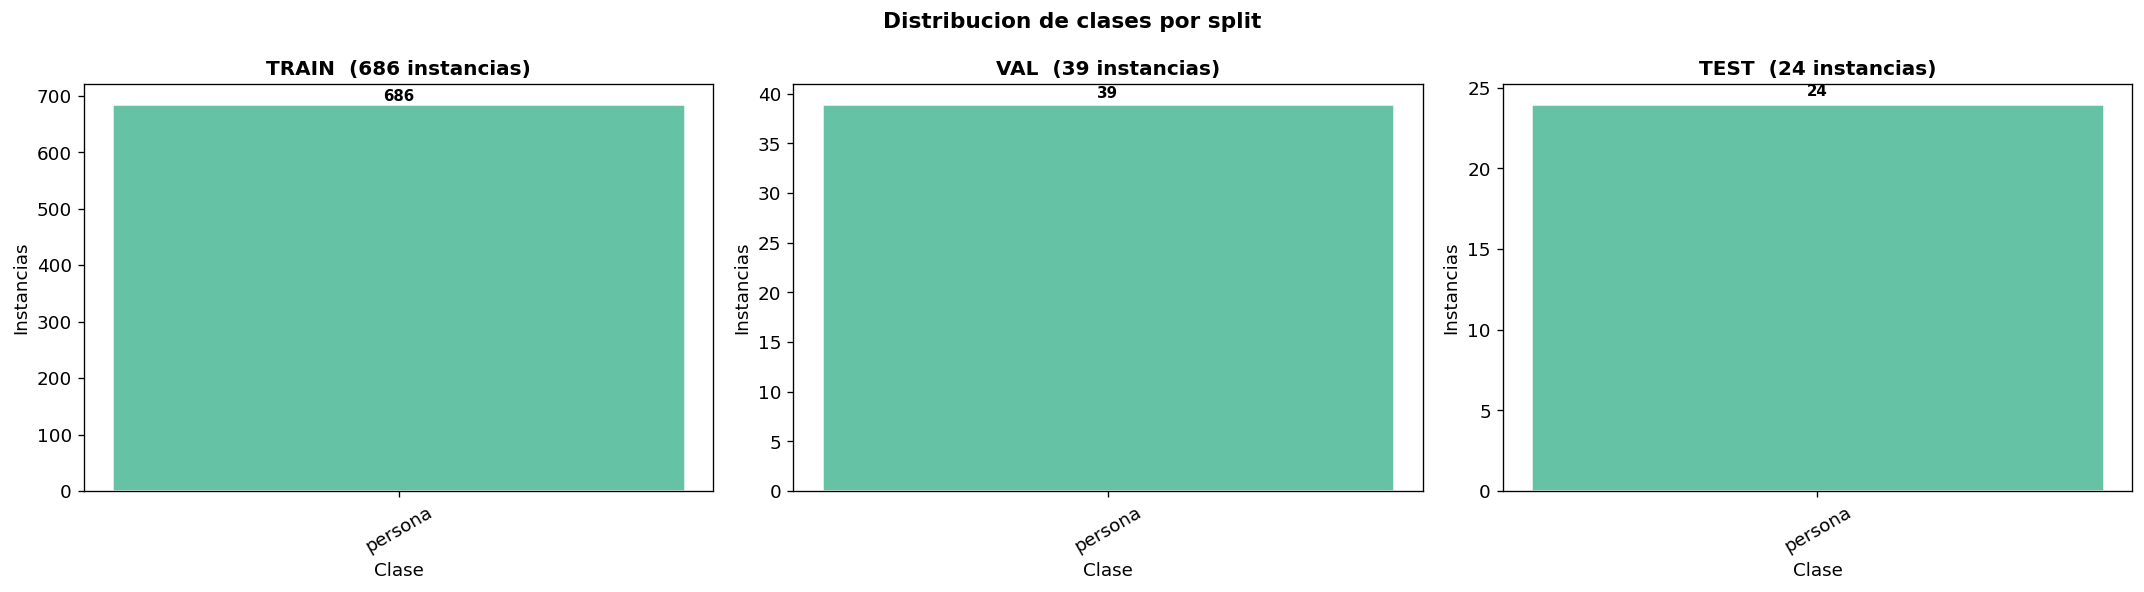

Dataset balanceado (ratio max/min: 1.0x).


In [17]:
def class_counts_per_split(stats, class_names):
    result = {}
    for split, d in stats.items():
        counts = {name: 0 for name in class_names}
        if not d['lbl_dir'].exists():
            continue
        for lbl_file in d['lbl_dir'].glob('*.txt'):
            with open(lbl_file) as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        cid = int(parts[0])
                        if cid < len(class_names):
                            counts[class_names[cid]] += 1
        result[split] = counts
    return result

class_counts = class_counts_per_split(stats, names_list)

n = len(class_counts)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), squeeze=False)
colors = plt.cm.Set2(np.linspace(0, 1, len(names_list)))

for ax, (split, counts) in zip(axes[0], class_counts.items()):
    bars = ax.bar(counts.keys(), counts.values(), color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{split.upper()}  ({sum(counts.values())} instancias)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Clase')
    ax.set_ylabel('Instancias')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Distribucion de clases por split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

if 'train' in class_counts:
    vals = list(class_counts['train'].values())
    if min(vals) > 0:
        ratio = max(vals) / min(vals)
        if ratio > 3:
            print(f'Desbalance en train: {ratio:.1f}x entre la clase mas frecuente y la menos frecuente.')
            print('Monitorear el recall por clase durante el entrenamiento.')
        else:
            print(f'Dataset balanceado (ratio max/min: {ratio:.1f}x).')

### Visualizacion de anotaciones

Revisar imagenes con sus bounding boxes antes de entrenar es una practica que ahorra tiempo. Detectas errores de anotacion, clases mal asignadas o problemas de calidad de imagen que los numeros no muestran. Es normal encontrar algunas anotaciones incorrectas, especialmente en datasets generados rapidamente.

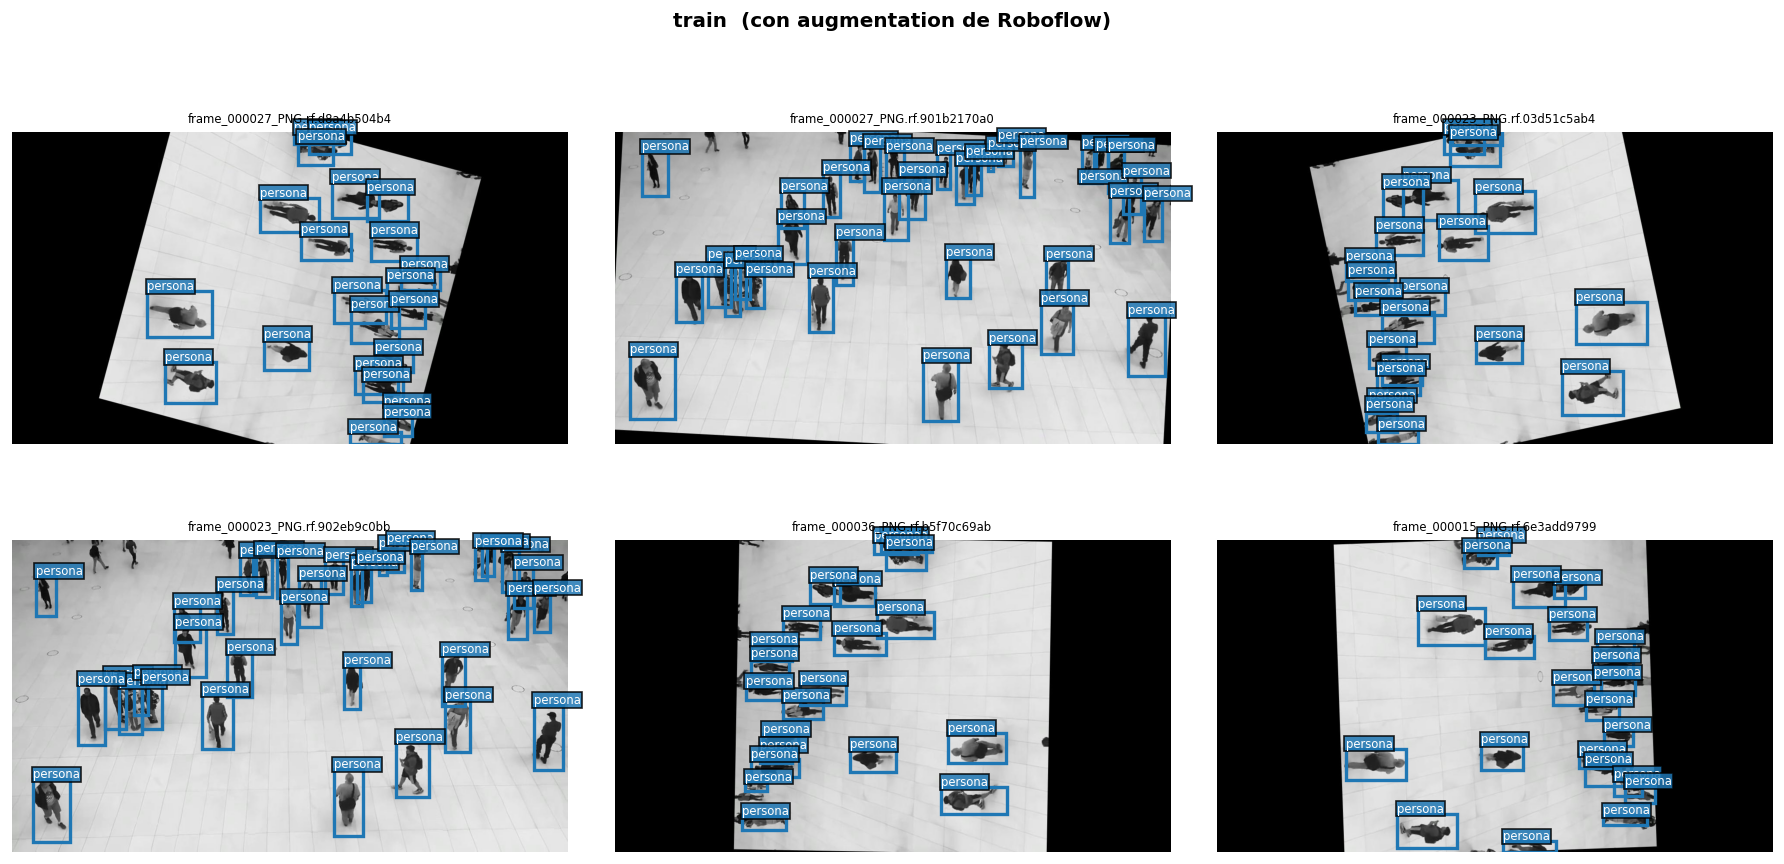

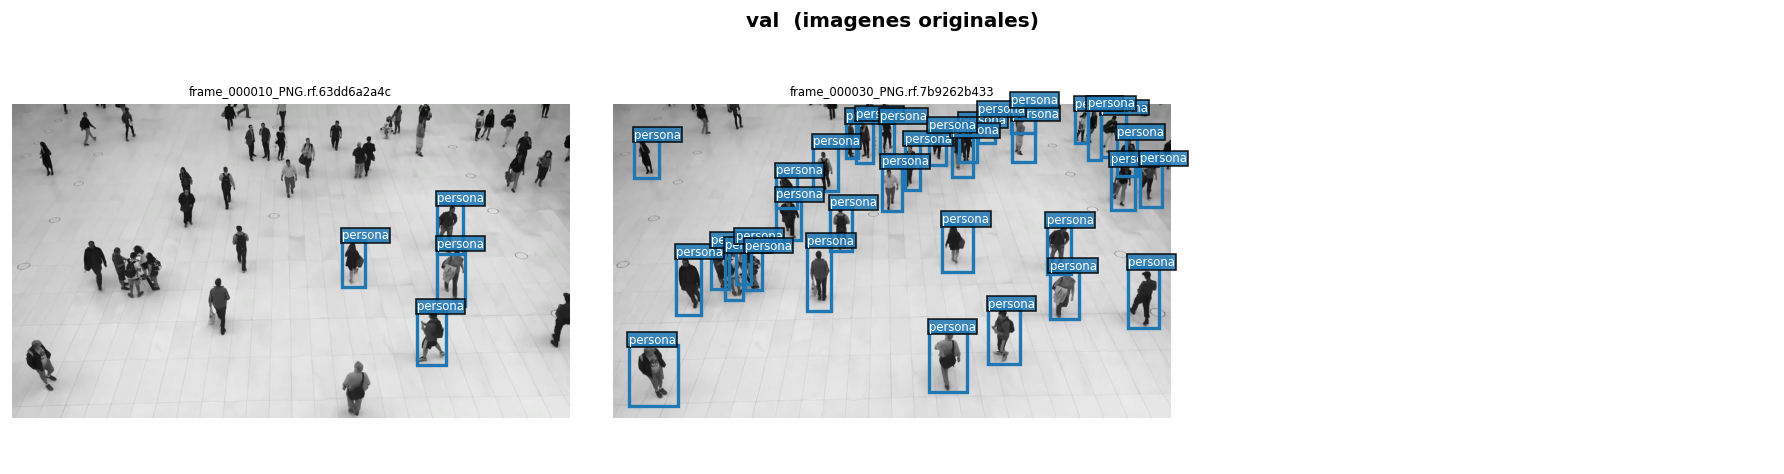

In [18]:
def visualize_split(stats, split, class_names, n=6, seed=42):
    if split not in stats or not stats[split]['img_paths']:
        print(f"No hay imagenes para el split '{split}'")
        return

    random.seed(seed)
    paths   = random.sample(stats[split]['img_paths'], min(n, len(stats[split]['img_paths'])))
    lbl_dir = stats[split]['lbl_dir']
    colors  = plt.cm.tab10(np.linspace(0, 1, max(len(class_names), 1)))

    cols = 3
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).flatten()

    for ax, img_path in zip(axes, paths):
        img  = Image.open(img_path).convert('RGB')
        iw, ih = img.size
        ax.imshow(img)

        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cid = int(parts[0])
                    xc, yc, bw, bh = map(float, parts[1:5])
                    x1, y1 = (xc - bw/2) * iw, (yc - bh/2) * ih
                    color  = colors[cid % len(colors)]
                    ax.add_patch(patches.Rectangle((x1, y1), bw * iw, bh * ih,
                                                   linewidth=2, edgecolor=color, facecolor='none'))
                    name = class_names[cid] if cid < len(class_names) else str(cid)
                    ax.text(x1, y1 - 3, name, fontsize=7, color='white',
                            bbox=dict(boxstyle='square,pad=0.1', facecolor=color, alpha=0.85))
        ax.set_title(img_path.name[:30], fontsize=7)
        ax.axis('off')

    for ax in axes[len(paths):]:
        ax.axis('off')

    label = 'train  (con augmentation de Roboflow)' if split == 'train' else f'{split}  (imagenes originales)'
    plt.suptitle(label, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_split(stats, 'train', names_list)
visualize_split(stats, 'val',   names_list)

### Augmentation offline vs. augmentation online

Conviene separar estas dos fuentes porque tienen roles distintos. El augmentation offline de Roboflow genera imagenes fijas en disco antes del entrenamiento: las ves cuando inspeccionas el set de train. El augmentation online de YOLO aplica transformaciones aleatorias en cada epoch sobre las imagenes originales, de modo que el modelo nunca ve dos veces exactamente la misma version de una imagen.

Cuando usas ambas en conjunto ten cuidado con la superposicion. Si Roboflow ya aplico flip horizontal con intensidad alta, poner tambien `fliplr=0.5` en YOLO duplica esa transformacion de manera innecesaria. En datasets pequenos puede ser positivo; en datasets mas grandes suele ser ruido sin ganancia real de generalizacion.

---
## Parte 5: Seleccion del modelo y configuracion del entrenamiento

La familia YOLOv11 tiene cinco variantes. Para fine-tuning la eleccion depende principalmente del tamaño del dataset: con menos de 500 imagenes el nano o el small evitan overfitting, con entre 500 y 5000 el small o el medium son un buen punto de partida, y con mas datos ya vale la pena probar el large.

| Modelo | Parametros | mAP COCO |
|---|---|---|
| yolo11n | 2.6 M | 39.5 |
| yolo11s | 9.4 M | 47.0 |
| yolo11m | 20.1 M | 51.5 |
| yolo11l | 25.3 M | 53.4 |
| yolo11x | 56.9 M | 54.7 |

En fine-tuning los pesos pre-entrenados no se descartan, se adaptan. El backbone ya sabe extraer features visuales generales desde COCO; lo que el modelo necesita aprender es asociar esos features con las clases especificas del dataset. Por eso converge en 50-100 epochs en lugar de los 300 o mas que requeriria entrenar desde cero.

In [19]:
BASE_MODEL = 'yolo11n.pt'   # cambiar a yolo11s.pt si tienes mas de 500 imagenes
MODEL_NAME = 'yolo11_sesion6'

model = YOLO(BASE_MODEL)
print(f'Modelo     : {BASE_MODEL}')
print(f'Parametros : {sum(p.numel() for p in model.model.parameters()):,}')

results = model.train(
    data    = str(yaml_fixed_path),
    epochs  = 100,
    patience= 20,      # para el entrenamiento si no mejora en 20 epochs seguidos
    batch   = 16,      # reducir a 8 si Colab da errores de memoria
    imgsz   = 640,
    device  = device,
    workers = 2,
    project = str(MODELS_DIR),
    name    = MODEL_NAME,
    exist_ok= True,
    plots   = True,
)

TRAIN_DIR = MODELS_DIR / MODEL_NAME
print(f'\nResultados guardados en: {TRAIN_DIR}')

Modelo     : yolo11n.pt
Parametros : 2,624,080
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/curso_cv/datasets/human_tracking_2/data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_sesion6, nbs=64, nm

---
## Parte 6: Entrenamiento

Durante cada epoch las imagenes pasan por el backbone para extraer features, luego por el neck que fusiona representaciones de distintas escalas, y finalmente por el head que predice los bounding boxes y las clases. El error se calcula con tres componentes: box loss para la localizacion, cls loss para la clasificacion y DFL loss para la distribucion de probabilidad de los bordes del bounding box.

Algunas cosas que suelen indicar problemas: si el box loss no baja en las primeras 10-15 epochs, verifica que las rutas en el YAML son correctas y que las anotaciones no tienen coordenadas fuera de rango. Si el cls loss se estanca con valores altos, suele ser desbalance de clases o learning rate incorrecto. Si el val loss empieza a subir mientras el train loss sigue bajando, es overfitting y el early stopping deberia intervenir.

In [20]:
results_csv = TRAIN_DIR / 'results.csv'
if not results_csv.exists():
    candidates = list(MODELS_DIR.glob('**/results.csv'))
    if candidates:
        results_csv = sorted(candidates)[-1]
        print(f'results.csv: {results_csv}')

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

map50_col   = next((c for c in df.columns if 'mAP50' in c and '95' not in c), None)
map5095_col = next((c for c in df.columns if 'mAP50-95' in c or 'mAP50:95' in c), None)
prec_col    = next((c for c in df.columns if 'precision' in c.lower()), None)
rec_col     = next((c for c in df.columns if 'recall'    in c.lower()), None)

print(f'Epochs: {len(df)}\n')
print(f"{'Metrica':<15} {'Mejor':>8} {'Epoch':>6} {'Ultimo':>8}")
print('-' * 45)
for name, col in [('mAP@50', map50_col), ('mAP@50:95', map5095_col),
                  ('Precision', prec_col), ('Recall', rec_col)]:
    if col and col in df.columns:
        best = df[col].max()
        ep   = df[col].idxmax() + 1
        last = df[col].iloc[-1]
        print(f'{name:<15} {best:>8.4f} {ep:>6} {last:>8.4f}')

Epochs: 64

Metrica            Mejor  Epoch   Ultimo
---------------------------------------------
mAP@50            0.7078     44   0.5373
mAP@50:95         0.3475     44   0.2544
Precision         0.6004     32   0.4796
Recall            1.0000      8   0.8974


---
## Parte 7: Metricas de entrenamiento

Las metricas principales son mAP@50 y mAP@50:95. La primera considera como correcta cualquier deteccion con IoU mayor o igual a 0.5 respecto al ground truth. La segunda promedia el mAP a distintos umbrales de IoU desde 0.5 hasta 0.95, en pasos de 0.05. En terminos practicos: mAP@50 es mas permisivo con la localizacion, mAP@50:95 penaliza los boxes que no coinciden bien aunque la clase sea correcta.

Precision mide que porcentaje de lo que el modelo detecto es realmente un objeto de esa clase. Recall mide que porcentaje de los objetos reales fue detectado. Si subes el umbral de confianza, precision sube y recall baja. La curva PR muestra ese trade-off a lo largo de todos los umbrales posibles.

In [21]:
results_csv = TRAIN_DIR / 'results.csv'
if not results_csv.exists():
    candidates = list(RUNS_DIR.glob('**/results.csv'))
    if candidates:
        results_csv = sorted(candidates)[-1]
        print(f'results.csv: {results_csv}')

df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

map50_col   = next((c for c in df.columns if 'mAP50' in c and '95' not in c), None)
map5095_col = next((c for c in df.columns if 'mAP50-95' in c or 'mAP50:95' in c), None)
prec_col    = next((c for c in df.columns if 'precision' in c.lower()), None)
rec_col     = next((c for c in df.columns if 'recall'    in c.lower()), None)

print(f'Epochs: {len(df)}\n')
print(f"{'Metrica':<15} {'Mejor':>8} {'Epoch':>6} {'Ultimo':>8}")
print('-' * 45)
for name, col in [('mAP@50', map50_col), ('mAP@50:95', map5095_col),
                  ('Precision', prec_col), ('Recall', rec_col)]:
    if col and col in df.columns:
        best = df[col].max()
        ep   = df[col].idxmax() + 1
        last = df[col].iloc[-1]
        print(f'{name:<15} {best:>8.4f} {ep:>6} {last:>8.4f}')

Epochs: 64

Metrica            Mejor  Epoch   Ultimo
---------------------------------------------
mAP@50            0.7078     44   0.5373
mAP@50:95         0.3475     44   0.2544
Precision         0.6004     32   0.4796
Recall            1.0000      8   0.8974


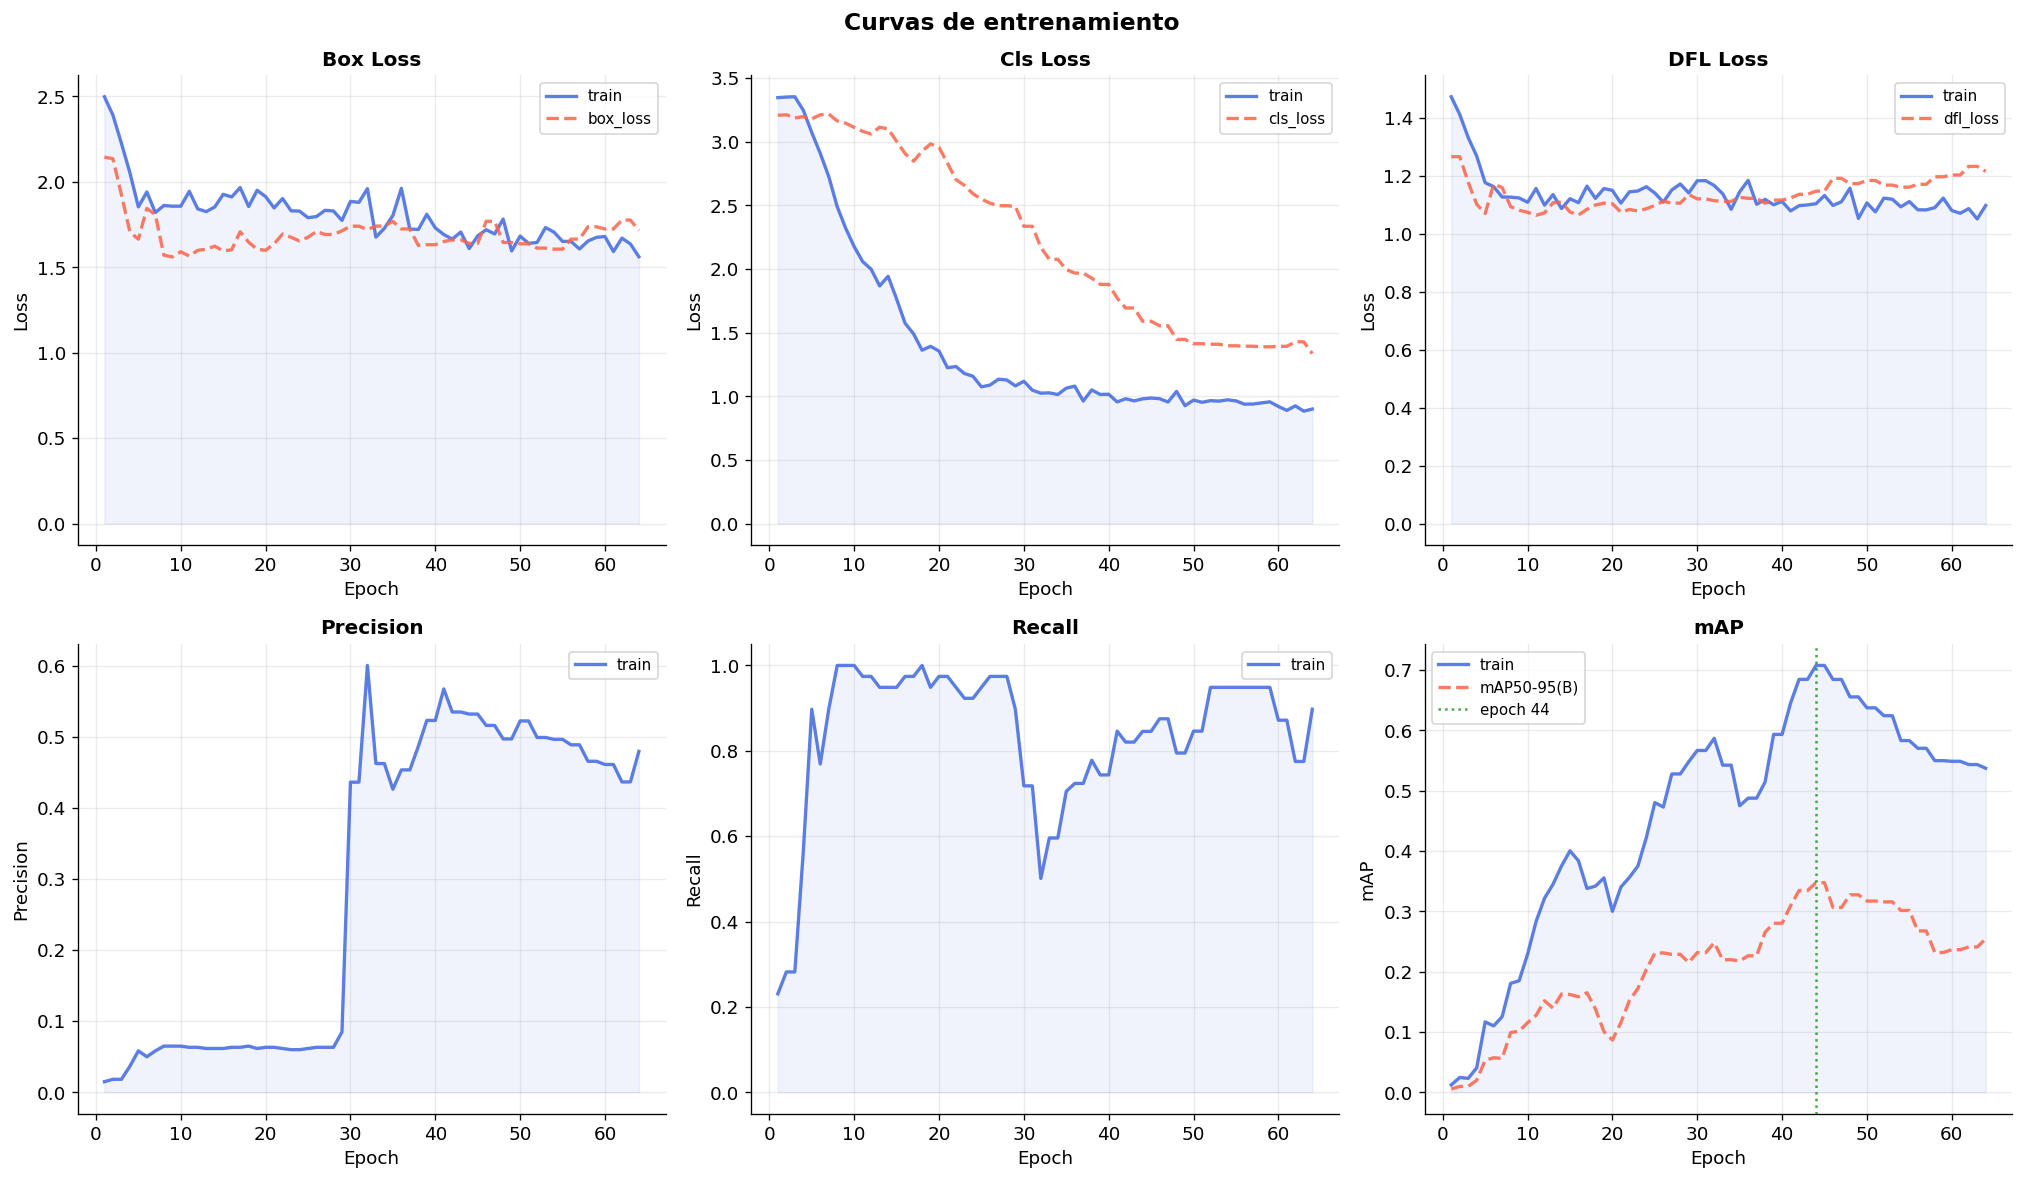

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes   = axes.flatten()
epochs = range(1, len(df) + 1)

box_train = next((c for c in df.columns if 'train' in c and 'box' in c), None)
box_val   = next((c for c in df.columns if 'val'   in c and 'box' in c), None)
cls_train = next((c for c in df.columns if 'train' in c and 'cls' in c), None)
cls_val   = next((c for c in df.columns if 'val'   in c and 'cls' in c), None)
dfl_train = next((c for c in df.columns if 'train' in c and 'dfl' in c), None)
dfl_val   = next((c for c in df.columns if 'val'   in c and 'dfl' in c), None)

panels = [
    (box_train,  box_val,    'Box Loss',  'Loss'),
    (cls_train,  cls_val,    'Cls Loss',  'Loss'),
    (dfl_train,  dfl_val,    'DFL Loss',  'Loss'),
    (prec_col,   None,       'Precision', 'Precision'),
    (rec_col,    None,       'Recall',    'Recall'),
    (map50_col,  map5095_col,'mAP',       'mAP'),
]

for ax, (tc, vc, title, ylabel) in zip(axes, panels):
    if tc and tc in df.columns:
        ax.plot(epochs, df[tc], color='royalblue', lw=2, label='train', alpha=0.85)
        ax.fill_between(epochs, df[tc], alpha=0.08, color='royalblue')
    if vc and vc in df.columns:
        ax.plot(epochs, df[vc], color='tomato', lw=2, ls='--',
                label=vc.split('/')[-1], alpha=0.85)
    if tc == map50_col and tc in df.columns:
        best_ep = df[tc].idxmax()
        ax.axvline(x=best_ep + 1, color='green', ls=':', lw=1.5, alpha=0.7,
                   label=f'epoch {best_ep + 1}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Curvas de entrenamiento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

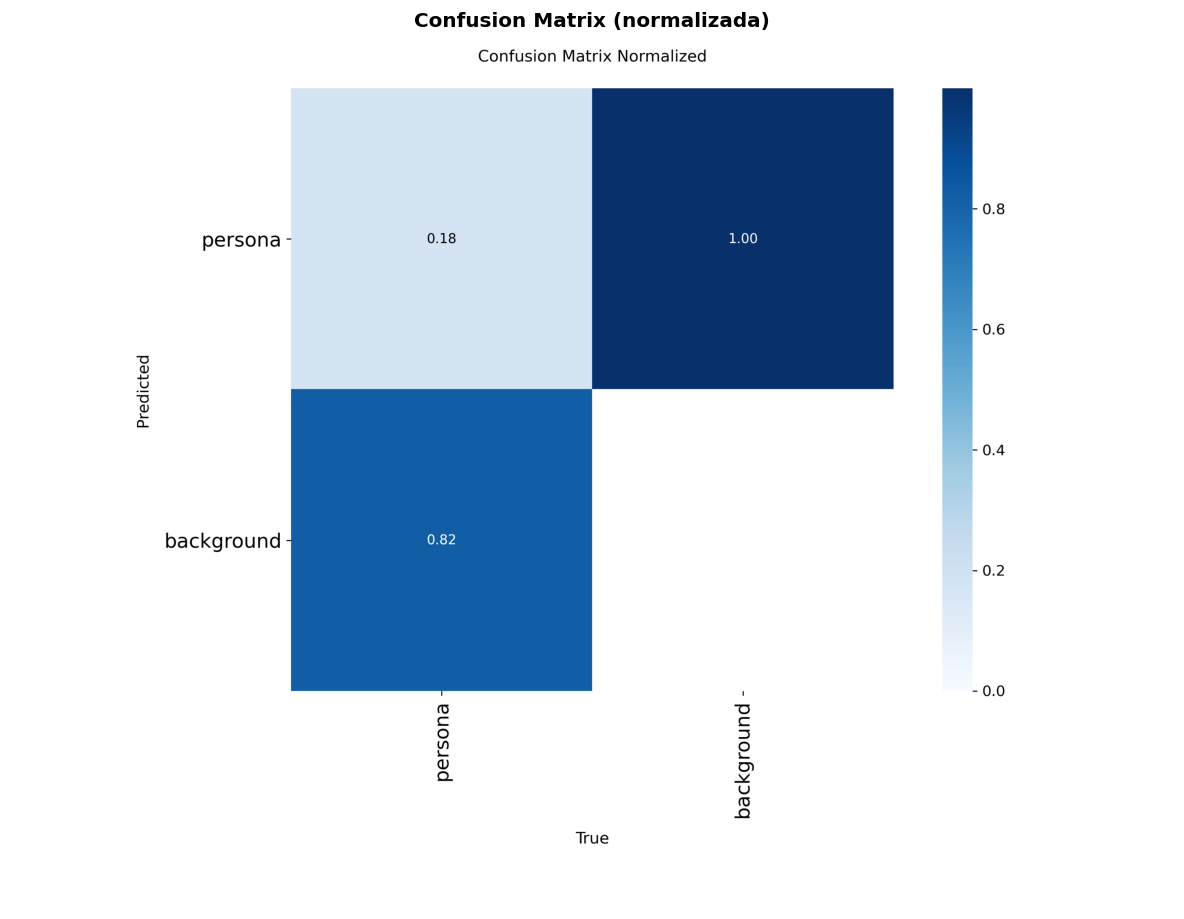

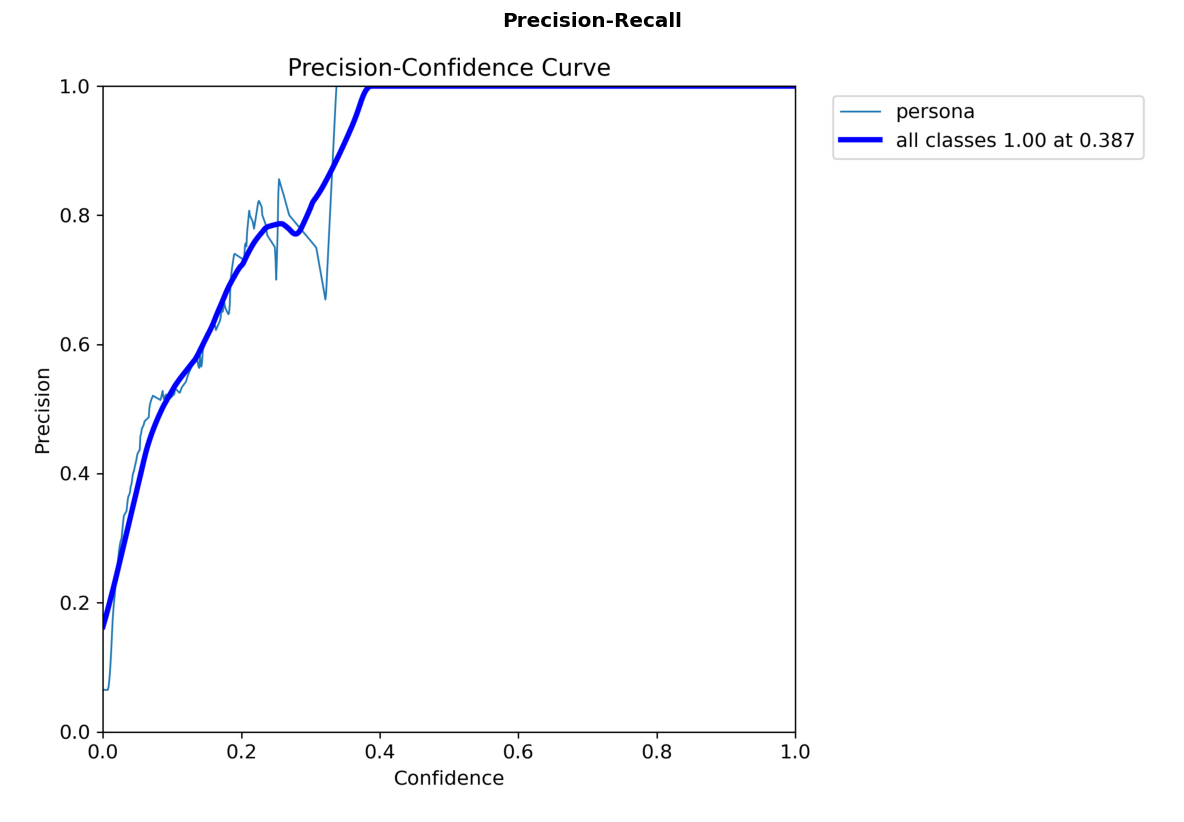

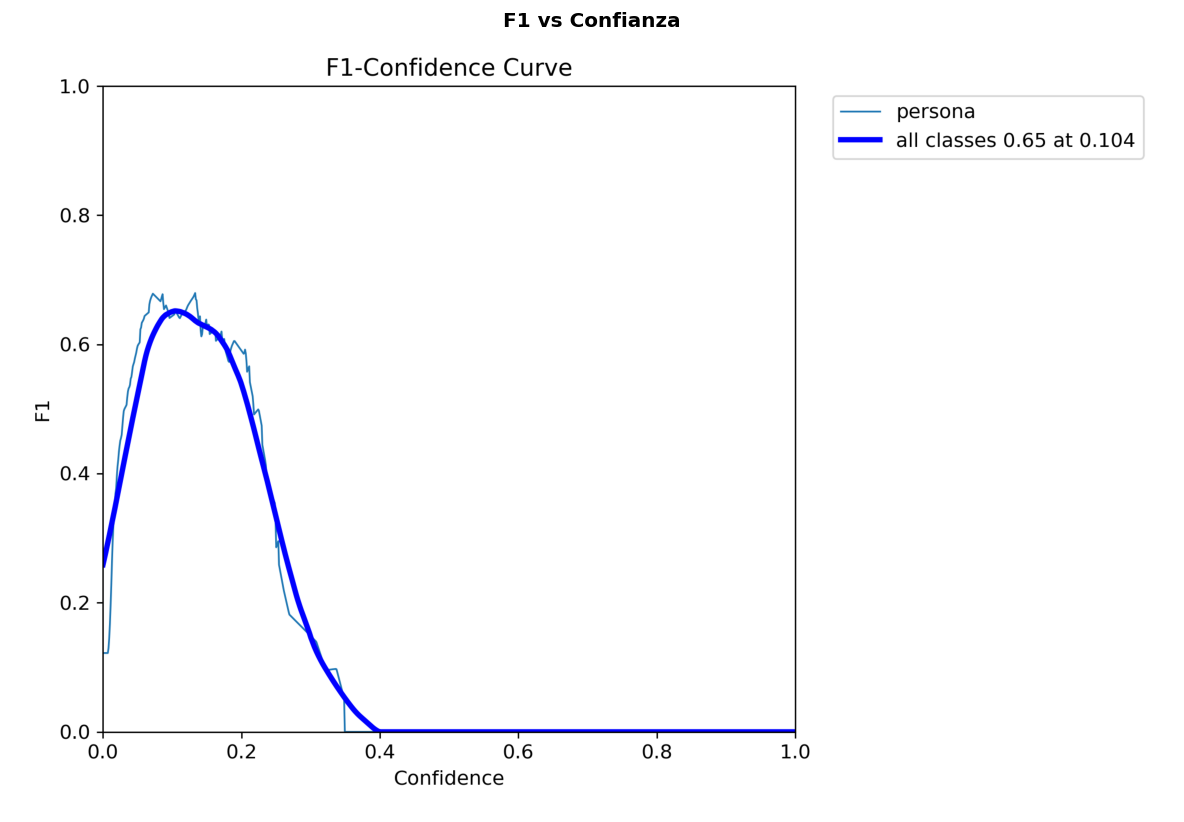

In [30]:
# YOLOv11 genera estos graficos automaticamente durante el entrenamiento
for filename, title, fs in [
    ('confusion_matrix_normalized.png', 'Confusion Matrix (normalizada)', (10, 8)),
    ('BoxP_curve.png',                    'Precision-Recall',               (10, 7)),
    ('BoxF1_curve.png',                    'F1 vs Confianza',                (10, 7)),
]:
    path = TRAIN_DIR / filename
    if path.exists():
        fig, ax = plt.subplots(figsize=fs)
        ax.imshow(Image.open(path))
        ax.axis('off')
        ax.set_title(title, fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print(f'No encontrado: {filename}')

En la confusion matrix la diagonal principal representa las detecciones correctas. La columna de background FP muestra objetos detectados que en realidad no existen en la imagen. La fila de background FN muestra objetos reales que el modelo no detecto. Las confusiones entre clases suelen indicar que esas clases comparten features similares o que las anotaciones no son lo suficientemente consistentes para separarlas.

---
## Parte 8: Evaluacion formal

Las curvas de entrenamiento muestran la tendencia epoch a epoch, pero el numero definitivo viene de ejecutar `model.val()` sobre el mejor checkpoint. Hay una diferencia importante entre `best.pt` y `last.pt`: el primero corresponde al epoch con mejor mAP en validacion durante el entrenamiento, el segundo al ultimo epoch ejecutado. En la mayoria de los casos `best.pt` es lo que se quiere para produccion.

In [24]:
best_pt = TRAIN_DIR / 'weights' / 'best.pt'
last_pt = TRAIN_DIR / 'weights' / 'last.pt'

checkpoint = best_pt if best_pt.exists() else last_pt
print(f'Checkpoint: {checkpoint.name}  ({checkpoint.stat().st_size / 1e6:.1f} MB)')

best_model = YOLO(str(checkpoint))

val_metrics = best_model.val(
    data=str(yaml_fixed_path),
    split='val',
    batch=16,
    device=device,
    verbose=False,
    plots=True
)

print('\nResultados en validacion:')
print(f'  mAP@50    : {val_metrics.box.map50:.4f}')
print(f'  mAP@50:95 : {val_metrics.box.map:.4f}')
print(f'  Precision : {val_metrics.box.mp:.4f}')
print(f'  Recall    : {val_metrics.box.mr:.4f}')
print()
print(f"  {'Clase':<20} {'AP@50':>8}")
print(f"  {'-' * 30}")
for i, name in enumerate(names_list):
    if hasattr(val_metrics.box, 'ap50') and i < len(val_metrics.box.ap50):
        print(f'  {name:<20} {val_metrics.box.ap50[i]:>8.4f}')

Checkpoint: best.pt  (5.4 MB)
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.2 ms, read: 30.7±1.5 MB/s, size: 62.3 KB)
val: Scanning /content/drive/MyDrive/curso_cv/datasets/human_tracking_2/valid/labels.cache... 2 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2/2 699.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 7.2it/s 0.1s
                   all          2         39      0.532      0.845      0.709      0.352
Speed: 0.7ms preprocess, 54.5ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to /content/runs/detect/val

Resultados en validacion:
  mAP@50    : 0.7090
  mAP@50:95 : 0.3520
  Precision : 0.5319
  Recall    : 0.8448

  Clase                   AP@50
  ------------------------------
  persona                0.7090


---
## Parte 9: Inferencia y comparativa con el baseline

El umbral de confianza (`conf`) y el IoU de NMS (`iou`) son los dos parametros que mas se ajustan al momento del deployment. Subir `conf` reduce las falsas alarmas pero puede perder detecciones de baja confianza. Bajar `iou` hace que NMS sea mas agresivo y elimina mas boxes solapadas. Los valores por defecto de YOLO (0.25 y 0.45) son un punto de partida razonable para explorar.

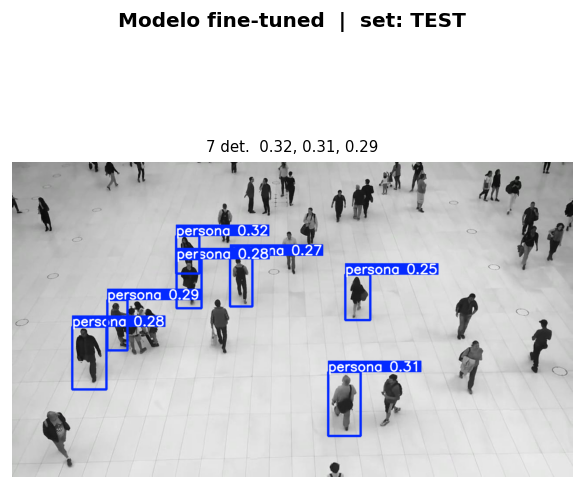

In [25]:
test_key   = 'test' if 'test' in stats and stats['test']['img_paths'] else 'val'
test_paths = stats[test_key]['img_paths']

n_show  = min(4, len(test_paths))
sample  = random.sample(test_paths, n_show)
fine_r  = best_model([str(p) for p in sample], conf=0.25, iou=0.45, verbose=False)

fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
if n_show == 1:
    axes = [axes]

for ax, res, p in zip(axes, fine_r, sample):
    ann = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(ann)
    confs = [f'{float(b.conf):.2f}' for b in res.boxes]
    ax.set_title(f"{len(res.boxes)} det.  {', '.join(confs[:3])}", fontsize=9)
    ax.axis('off')

plt.suptitle(f'Modelo fine-tuned  |  set: {test_key.upper()}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

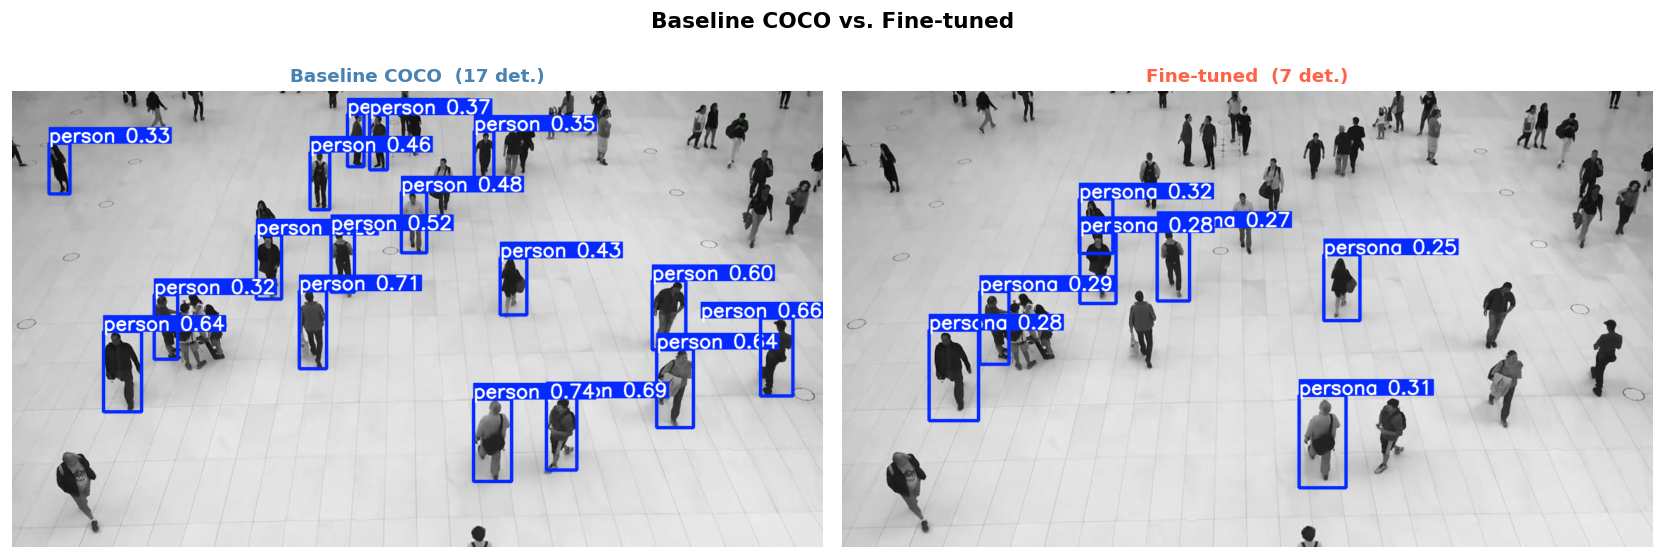

In [26]:
# Comparativa con el modelo base entrenado en COCO
baseline = YOLO('yolo11n.pt')

n_cmp   = min(3, len(test_paths))
cmp_set = random.sample(test_paths, n_cmp)

fig, axes = plt.subplots(n_cmp, 2, figsize=(14, 5 * n_cmp))
if n_cmp == 1:
    axes = [axes]

for row, img_path in zip(axes, cmp_set):
    p_str = str(img_path)

    base_res = baseline(p_str, conf=0.25, verbose=False)[0]
    row[0].imshow(cv2.cvtColor(base_res.plot(), cv2.COLOR_BGR2RGB))
    row[0].set_title(f'Baseline COCO  ({len(base_res.boxes)} det.)',
                     fontsize=11, color='steelblue', fontweight='bold')
    row[0].axis('off')

    ft_res = best_model(p_str, conf=0.25, verbose=False)[0]
    row[1].imshow(cv2.cvtColor(ft_res.plot(), cv2.COLOR_BGR2RGB))
    row[1].set_title(f'Fine-tuned  ({len(ft_res.boxes)} det.)',
                     fontsize=11, color='tomato', fontweight='bold')
    row[1].axis('off')

plt.suptitle('Baseline COCO vs. Fine-tuned', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Parte 10: Exportacion

Una vez que el rendimiento es satisfactorio, el siguiente paso es exportar al formato que corresponde al entorno de deployment. PyTorch es para desarrollo y experimentacion. ONNX es el formato mas portable: corre en cualquier framework, sistema operativo y hardware sin depender de PyTorch. Para servidores con GPU NVIDIA, TensorRT da la mejor latencia porque optimiza el grafo especificamente para esa arquitectura.

El modelo exportado se copia a Drive para que este disponible fuera de Colab.

In [27]:
print('Exportando a ONNX...')
onnx_path = best_model.export(
    format  = 'onnx',
    imgsz   = 640,
    dynamic = True,
    simplify= True,
    opset   = 17
)

# Copiar a outputs en Drive
onnx_dest = OUTPUTS_DIR / Path(onnx_path).name
shutil.copy2(onnx_path, onnx_dest)
print(f'Guardado en Drive: {onnx_dest}')

print('\nTamanos:')
for label, path in [('PyTorch (best.pt)', checkpoint), ('ONNX', onnx_dest)]:
    if Path(path).exists():
        mb = Path(path).stat().st_size / 1e6
        print(f'  {label:<22}: {mb:.2f} MB')

Exportando a ONNX...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/drive/MyDrive/curso_cv/models/yolo11_sesion6/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 216ms
Prepared 4 packages in 6.41s
Installed 4 packages in 253ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.2
 + onnxslim==0.1.87

requirements: AutoUpdate success ✅ 7.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.87...
ONNX:

In [28]:
if test_paths:
    bench_img = str(test_paths[0])
    N = 50

    for _ in range(5):  # warm-up
        best_model(bench_img, verbose=False)

    times = []
    for _ in range(N):
        t0 = time.perf_counter()
        best_model(bench_img, verbose=False)
        times.append((time.perf_counter() - t0) * 1000)

    avg = np.mean(times)
    std = np.std(times)

    print(f'Latencia ({N} inferencias, {device.upper()}):')
    print(f'  {avg:.2f} +/- {std:.2f} ms   |   {1000 / avg:.1f} FPS')
    print()
    print('Referencia:')
    print('  > 30 FPS : tiempo real')
    print('  > 10 FPS : near real-time')
    print('  < 10 FPS : procesamiento batch / offline')

Latencia (50 inferencias, CUDA):
  21.58 +/- 4.11 ms   |   46.3 FPS

Referencia:
  > 30 FPS : tiempo real
  > 10 FPS : near real-time
  < 10 FPS : procesamiento batch / offline


---
## Resumen

En esta sesion completamos el flujo de fine-tuning de principio a fin: descarga desde Roboflow, analisis y correccion del `data.yaml`, exploracion de datos, configuracion del entrenamiento, analisis de metricas, evaluacion formal, comparativa con el baseline y exportacion.

Todo queda guardado en Drive en `Clase_CV/Sesion6/runs`. En cualquier sesion futura se puede reanudar el analisis sin repetir el entrenamiento: solo montar Drive, cargar `best.pt` y ejecutar las celdas de evaluacion o inferencia.

En la Sesion 7 vamos a ver como automatizar la busqueda de hiperparametros con Ray Tune y como hacer un analisis de errores sistematico para identificar que mejorar en el dataset o en la configuracion del modelo.